# Импорты и зависимости

In [68]:
!pip install ollama sentence-transformers scikit-learn

In [69]:
!sudo apt-get install zstd && curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [70]:
import subprocess
import threading
import json
import re
import ollama
from collections import defaultdict
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from typing import List, Dict, Tuple

# Запуск Ollama

In [ ]:
def run_ollama_serve(): # обычный вызов ollama serve блочит весь ноутбук
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

thread = threading.Thread(target=run_ollama_serve)
thread.daemon = True
thread.start()

In [71]:
!ollama pull llama3.2:1b

# Класс модели и датасет

In [72]:
class DEER:
    def __init__(self, model_name: str = "llama3.2:1b",
                 lambda1: float = 1.0, lambda2: float = 1.0,
                 we: float = 1.0, wc: float = 1.0, wo: float = 0.01,
                 context_len: int = 2, theta_fn: float = 0.95,
                 M: int = 2, K: int = 2):

        self.model_name = model_name
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.we, self.wc, self.wo = we, wc, wo
        self.context_len = context_len
        self.theta_fn = theta_fn
        self.M = M
        self.K = K

        self.token_stats: Dict[str, Dict[str, int]] = defaultdict(lambda: {"entity": 0, "context": 0, "other": 0})
        self.total_counts = {"entity": 0, "context": 0, "other": 0}
        self.train_examples: List[Dict] = []

        self.vectorizer = TfidfVectorizer()
        self.train_vectors = None

    def prepare(self, train_data: List[Tuple[str, List[Dict]]]):
        """train_data = [(text, [ {"name": "...", "type": "..."}, ... ])]"""
        for text, entities in train_data:
            tokens = self._tokenize(text)
            labels = ["other"] * len(tokens)

            for ent in entities:
                ent_tokens = self._tokenize(ent["name"])
                for i in range(len(tokens) - len(ent_tokens) + 1):
                    if tokens[i:i+len(ent_tokens)] == ent_tokens:
                        for j in range(i, i + len(ent_tokens)):
                            labels[j] = "entity"
                        for j in range(max(0, i - self.context_len), min(len(tokens), i + len(ent_tokens) + self.context_len)):
                            if labels[j] == "other":
                                labels[j] = "context"

            for t, label in zip(tokens, labels):
                self.token_stats[t][label] += 1
                self.total_counts[label] += 1

            self.train_examples.append({"text": text, "entities": entities, "tokens": tokens})

        texts = [ex["text"] for ex in self.train_examples]
        self.train_vectors = self.vectorizer.fit_transform(texts).toarray()

        print(f"DEER обучился на {len(train_data)} примерах")

    def _tokenize(self, text: str) -> List[str]:
        return re.findall(r"\w+(?:'\w+)?", text.lower())

    def _get_prob(self, token: str):
        stats = self.token_stats.get(token, {"entity": 0, "context": 0, "other": 0})
        total = sum(stats.values()) or 1
        return stats["entity"]/total, stats["context"]/total, stats["other"]/total

    def retrieve_demos(self, test_text: str, n: int = 8) -> List[Dict]:
        test_tokens = self._tokenize(test_text)
        scores = []

        test_vec = self.vectorizer.transform([test_text]).toarray()

        for i, ex in enumerate(self.train_examples):
            tok_score = sum(self._get_weight(t) for t in test_tokens if t in ex["tokens"]) / len(test_tokens) if test_tokens else 0
            emb_score = cosine_similarity(test_vec, [self.train_vectors[i]])[0][0]
            total_score = self.lambda1 * tok_score + self.lambda2 * emb_score
            scores.append((total_score, i))

        scores.sort(reverse=True)
        return [self.train_examples[i] for _, i in scores[:n]]

    def _get_weight(self, token: str):
        if token not in self.token_stats:
            return 1.0
        pe, pc, po = self._get_prob(token)
        return self.we * pe + self.wc * pc + self.wo * po

    def _llm_call(self, prompt: str) -> str:
        response = ollama.chat(
            model=self.model_name,
            messages=[{'role': 'user', 'content': prompt}],
            format='json'
        )
        return response['message']['content']

    def predict(self, test_text: str, n_demos: int = 8) -> Dict:
        demos = self.retrieve_demos(test_text, n_demos)
        icl_prompt = self._build_icl_prompt(test_text, demos)

        response = self._llm_call(icl_prompt)
        try:
            prediction = json.loads(response)
        except:
            prediction = {"named entities": []}

        final = self._error_reflection(test_text, prediction)
        return final

    def _build_icl_prompt(self, test_text: str, demos: List[Dict]) -> str:
        prompt = (
            'Here is the JSON template for named entity recognition:\n'
            '{"named entities": [{"name": "ent_name", "type": "ent_type"}, ...]}\n\n'
            'Identify named entities following the JSON template. '
            'If no entities, output {"named entities": []}\n\n'
        )
        for ex in demos:
            prompt += f'Input: {ex["text"]}\nOutput: {json.dumps({"named entities": ex["entities"]})}\n\n'
        prompt += f'Input: {test_text}\nOutput:'
        return prompt

    def _error_reflection(self, text: str, prediction: Dict) -> Dict:
        entities = prediction.get("named entities", [])
        tokens = self._tokenize(text)

        for t in tokens:
            pe, _, _ = self._get_prob(t)
            if t not in self.token_stats and self._is_high_context(t, tokens):
                self._reflect_unseen(text, t, entities)
            if pe > self.theta_fn and not any(t in e.get("name", "") for e in entities):
                self._reflect_false_negative(text, t, entities)

        for ent in entities[:]:
            if "city" in ent.get("name", "").lower():
                ent["name"] = ent["name"].replace(" city", "").strip()

        return {"named entities": entities}

    def _is_high_context(self, token: str, tokens: List[str]) -> bool:
        try:
            idx = tokens.index(token)
        except ValueError:
            return False
        for i in range(max(0, idx-2), min(len(tokens), idx+3)):
            if i == idx: continue
            pe, pc, _ = self._get_prob(tokens[i])
            if pe + pc > 0.3:
                return True
        return False

    def _reflect_unseen(self, text: str, token: str, entities: List):
        if len(token) > 2:
            entities.append({"name": token.capitalize(), "type": "PER"})

    def _reflect_false_negative(self, text: str, token: str, entities: List):
        entities.append({"name": token.capitalize(), "type": "MISC"})

In [73]:
from datasets import load_dataset

def load_conll2003_train(max_examples: int = None):
    dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
    train = dataset["train"]

    label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG",
                  "B-LOC", "I-LOC", "B-MISC", "I-MISC"]

    train_data = []
    for example in train:
        tokens = example["tokens"]
        ner_tags = example["ner_tags"]
        text = " ".join(tokens)

        entities = []
        i = 0
        while i < len(tokens):
            if ner_tags[i] != 0:
                tag = ner_tags[i]
                entity_type = label_list[tag].split("-")[-1]
                start = i
                while i < len(tokens) and ner_tags[i] != 0:
                    i += 1
                entity_name = " ".join(tokens[start:i])
                entities.append({"name": entity_name, "type": entity_type})
            else:
                i += 1

        train_data.append((text, entities))

        if max_examples and len(train_data) >= max_examples:
            break

    print(f"Тренировочный корпус загружен")
    return train_data

# Обучение

In [74]:
deer = DEER(model_name="llama3.2:1b")
train_data = load_conll2003_train()
deer.prepare(train_data)

Тренировочный корпус загружен
DEER обучился на 14041 примерах


# Демонстрация работы модели

In [76]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional

def visualize_entity_type_heatmap(prediction: Dict[str, List[Dict]],
                                  top_names: int = 10,
                                  ax: Optional[plt.Axes] = None,
                                  is_prediction: bool = True,
                                  vmin: Optional[int] = None,
                                  vmax: Optional[int] = None) -> plt.Axes:
    entities = prediction.get("named entities", [])

    pairs = defaultdict(int)
    name_total = Counter()
    for ent in entities:
        name = ent["name"]
        typ = ent["type"]
        pairs[(name, typ)] += 1
        name_total[name] += 1

    top_names_list = [name for name, _ in name_total.most_common(top_names)]

    types = set()
    for name in top_names_list:
        for (n, t), cnt in pairs.items():
            if n == name:
                types.add(t)
    types = sorted(types)

    data = []
    for name in top_names_list:
        row = [pairs.get((name, t), 0) for t in types]
        data.append(row)
    df = pd.DataFrame(data, index=top_names_list, columns=types)

    sns.heatmap(df,
                annot=True,
                fmt='d',
                cmap='Blues',
                linewidths=0.5,
                ax=ax,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': 'Количество'})

    ax.set_xlabel('Тип сущности')
    ax.set_ylabel('Имя сущности')
    ax.set_title('Предсказание' if is_prediction else 'На самом деле')


    return ax

In [77]:
test = train_data[123][0]
result = deer.predict(test, n_demos=4)

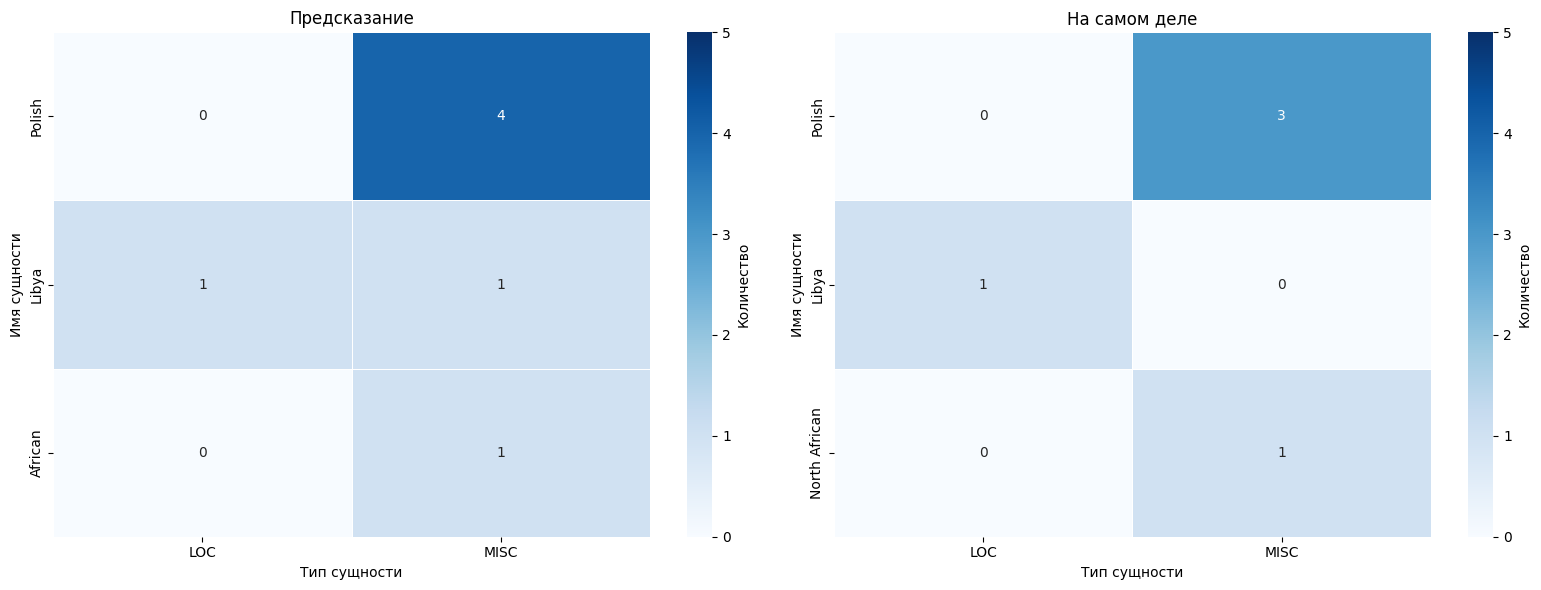

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
visualize_entity_type_heatmap(result, ax=axes[0], is_prediction=True, top_names=8, vmin=0, vmax=5)
visualize_entity_type_heatmap({'named entities': train_data[123][1]}, ax=axes[1], is_prediction=False, top_names=8, vmin=0, vmax=5)
plt.tight_layout()
plt.show()

# Итог
Была препарирована модель DEER, а затем использована для извлечения сущностей из случайного текста обучающего корпуса. Модель справляется с этой задачей хорошо, о чем свидательствует график выше